In [2]:
import scanpy as sc
import pandas as pd

dir0 = "/stomics_data/liminData/spatial_related_codes/spatial_biology/Visium/P19"
outdir = f"{dir0}/analysis"
sc.settings.figdir = outdir

In [1]:
# # read-in visium standard data and save as h5ad

# samples = ['B1','B2', 'T1', 'T2']
# for sp in samples:
#     file_dir = f"{dir0}/data/{sp}"
#     adata = sc.read_visium(path=file_dir, count_file="filtered_feature_bc_matrix.h5")
#     adata.write_h5ad(f"{dir0}/analysis/h5ad/{sp}_spatial.h5ad")
#     print(adata)

## Generate single-cell h5ad file
# samples = ['B1', 'T1', 'T2']

# for sp in samples:
#     fpath = f"{dir0}/data/single_cell/{sp}"
#     adata = sc.read_10x_mtx(
#         fpath,
#         var_names="gene_symbols",
#         cache=True
#     )

#     adata.write_h5ad(f"{dir0}/analysis/h5ad/{sp}_singlecell.h5ad")


# Integrate 2 Visium data with Harmony 

In [5]:
import scanpy as sc
import scanpy.external as sce
import harmonypy as hm


/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [6]:
# Preprocessing tumor1
file_path1 = f"{dir0}/analysis/h5ad/T1_spatial.h5ad"
adata1 = sc.read_h5ad(file_path1)
adata1.var_names_make_unique()
adata1.var['mt'] = adata1.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata1, qc_vars=['mt'], inplace=True)
sc.pp.normalize_total(adata1, target_sum=1e4)
sc.pp.log1p(adata1)
adata1.raw = adata1 # save lognorm for later DEG analysis

# Preprocessing tumor2
file_path2 = f"{dir0}/analysis/h5ad/T2_spatial.h5ad"
adata2 = sc.read_h5ad(file_path2)
adata2.var_names_make_unique()
adata2.var['mt'] = adata2.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata2, qc_vars=['mt'], inplace=True)
sc.pp.normalize_total(adata2, target_sum=1e4)
sc.pp.log1p(adata2)
adata2.raw = adata2

# Label and concatenate
adata1.obs["sample"] = "T1"
adata2.obs["sample"] = "T2"
# adata = adata1.concatenate(adata2, batch_key="batch_id")

import anndata as ad
adata = ad.concat(
    [adata1, adata2],
    label="sample",
    keys=["T1", "T2"],
    join = "outer",
    uns_merge="unique"
)

# Select highly variable genes across the combined datasets
sc.pp.highly_variable_genes(adata, min_mean=0.0125)
adata = adata[:, adata.var.highly_variable].copy()

# scale data and run PCA (required before Harmony)
sc.pp.scale(adata, max_value=10, zero_center=False)
sc.tl.pca(adata, svd_solver="arpack")



/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/anndata/_core

# harmony default parameters

2026-09-02 14:37:06,396 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-09-02 14:37:06,397 - harmonypy - INFO -   Parameters:
2026-09-02 14:37:06,398 - harmonypy - INFO -     max_iter_harmony: 10
2026-09-02 14:37:06,398 - harmonypy - INFO -     max_iter_kmeans: 20
2026-09-02 14:37:06,399 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-09-02 14:37:06,400 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-09-02 14:37:06,400 - harmonypy - INFO -     nclust: 100
2026-09-02 14:37:06,401 - harmonypy - INFO -     block_size: 0.05
2026-09-02 14:37:06,401 - harmonypy - INFO -     lamb: [1. 1.]
2026-09-02 14:37:06,402 - harmonypy - INFO -     theta: [2. 2.]
2026-09-02 14:37:06,403 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-09-02 14:37:06,403 - harmonypy - INFO -     verbose: True
2026-09-02 14:37:06,404 - harmonypy - INFO -     random_state: 0
2026-09-02 14:37:06,404 - harmonypy - INFO -   Data: 50 PCs × 4881 cells
2026-09-02 14:37:06,405 - harmonypy - INFO

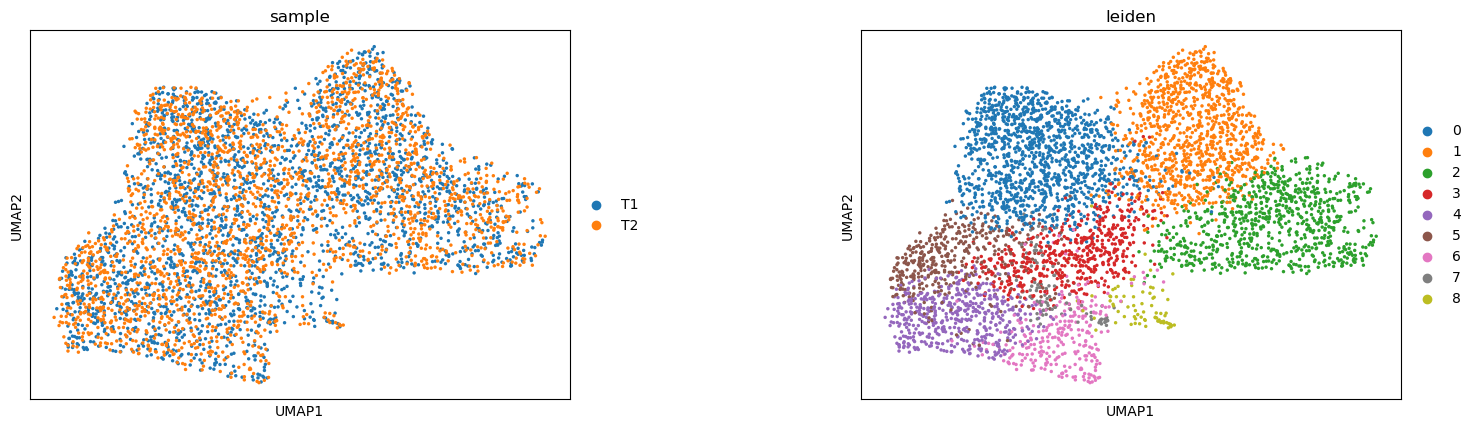

/tmp/ipykernel_158398/2633198697.py:28: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


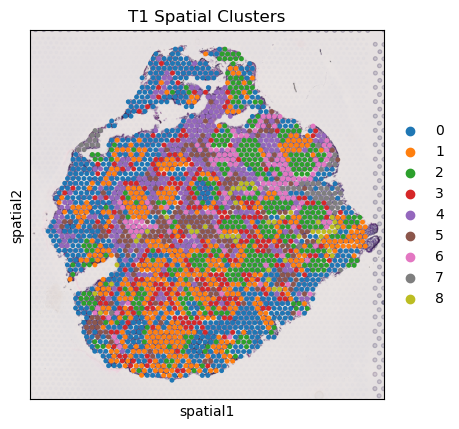

/tmp/ipykernel_158398/2633198697.py:37: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


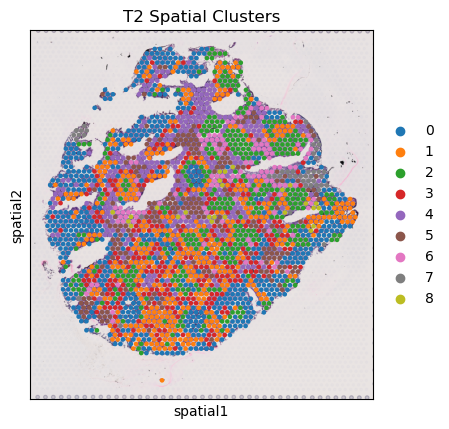

In [7]:
# Harmony Integration
pcs = adata.obsm["X_pca"] #
#harmony_out = hm.run_harmony(pcs, adata.obs, "batch_id") # old version
harmony_out = hm.run_harmony(
    pcs, adata.obs, "sample",
    #theta = 0.5,
    #sigma = 0.2,
    #max_iter_harmony = 5
) 

# Z_corr is already a numpy array with shape (n_cells, n_pcs)
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr

# Compute neighbors using the Harmony-corrected PCA space
sc.pp.neighbors(adata, use_rep="X_pca_harmony")

# Generate UMAP embeddings and clusters
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.8)

# Plot to verify integration success
sc.pl.umap(adata, color=["sample", "leiden"], wspace=0.4)

lib_id_t1 = "spaceranger110_count_38262_OTAR_LNGsp10206167_GRCh38-2020-A"
lib_id_t2 = "spaceranger110_count_38262_OTAR_LNGsp10206168_GRCh38-2020-A"

# Plot spatial clusters for Sample 1
sc.pl.spatial(
    adata[adata.obs["sample"] == "T1"],
    library_id = lib_id_t1,
    color="leiden",
    spot_size=200,
    title="T1 Spatial Clusters",
)

# Plot spatial clusters for Sample 2
sc.pl.spatial(
    adata[adata.obs["sample"] == "T2"],
    color="leiden",
    title="T2 Spatial Clusters",
    spot_size=200,
    library_id = lib_id_t2,
)

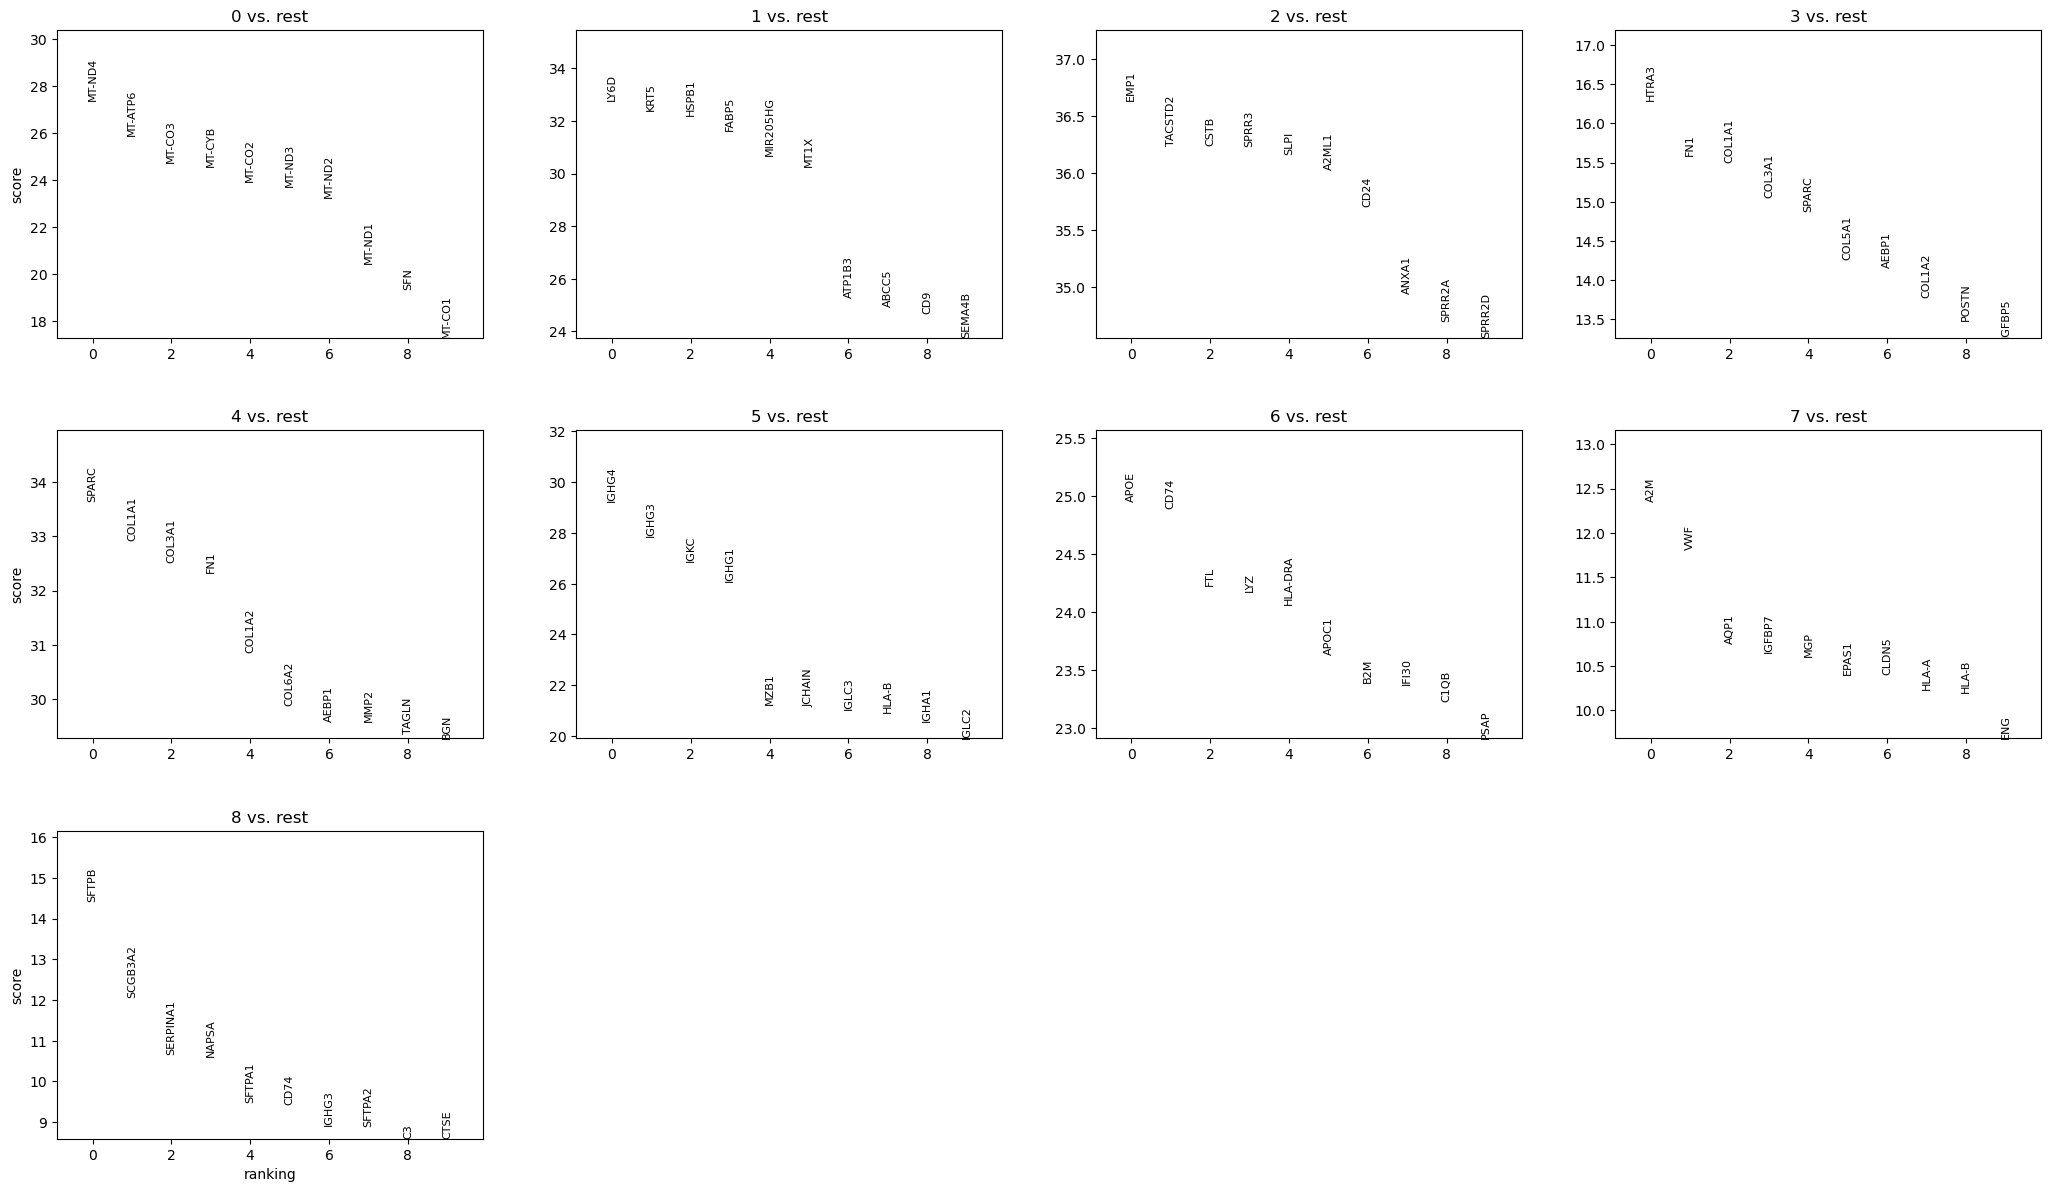

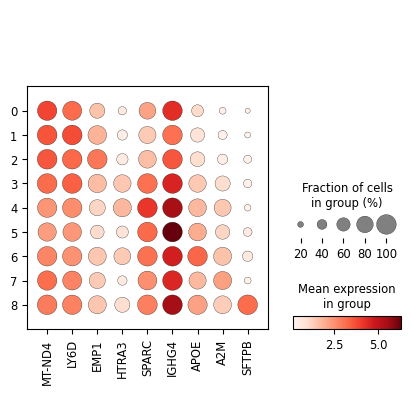

In [8]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

sc.pl.rank_genes_groups(adata, n_genes=0, sharey=False)

top_genes = [str(g) for g in adata.uns['rank_genes_groups']['names'][0]]
sc.pl.dotplot(adata, var_names=top_genes, groupby='leiden')

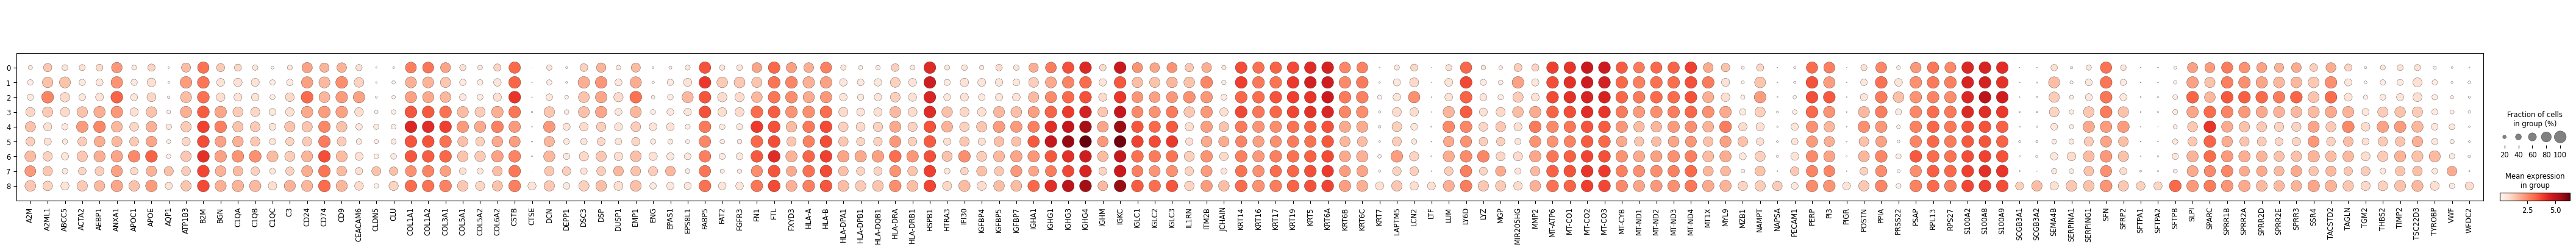

In [19]:
import numpy as np

# 1. Get the top 20 rows (ranks 0 to 19) across all clusters
names_array = adata.uns['rank_genes_groups']['names'][:20]
top_20_genes = np.unique([str(gene) for row in names_array for gene in row]).tolist()

# 3. Plot the dotplot
sc.pl.dotplot(adata, var_names=top_20_genes, groupby='leiden')

# Celltype anntation

There are many ways to do celltype annotation.
1) Marker genes based celltype annotation.
2) Reference-based celltype annotation, ex, using single-cell atlas database for spatial data annotation. 
3) paired single-cell based celltype inferrence, such as cell2location.

You can try different methods or tools to compare which annotation methods best annotate your celltypes.
